# Why do we need ARC?
Training large AI models can take days or even weeks of expensive GPU time. Because neural networks do millions of calculations a second, a single mathematical error—like a sudden "loss explosion"—can permanently corrupt the model. 

In standard PyTorch, this completely crashes your training. You lose your progress, waste days of compute time, and have to manually restart from scratch. 

**ARC (Autonomous Recovery Controller)** solves this by acting like an automatic airbag. If it detects the math exploding, it instantly catches the error, throws away the corrupted data, rolls back to the last safe step, and resumes training—all without any human intervention.

### ARC Quickstart Tutorial
This interactive notebook demonstrates how ARC automatically catches training instabilities (like loss explosions) and rolls back to a safe state without crashing. Let's set up a basic model and protect it with `ArcV2`.

In [9]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from arc import ArcV2

# 1. Simple Model & Optimizer
model = nn.Linear(10, 2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 2. Wrap it with the recommended modern API
arc = ArcV2.auto(model, optimizer)

print("ARC Controller Initialized.")

Arc attached to Linear
Device: cpu
Signal collectors: 5
   ARC v2.0 Auto-configured:
   Model: 22 params, 1 layers
   Task: classification
   Safety: standard
   Features: EWC=True, UQ=conformal, Adv=False
ARC Controller Initialized.


### The Training Loop
We will simulate a standard PyTorch training loop for 20 steps. At step 10, we will intentionally inject a massive loss spike to simulate a catastrophic math failure. Watch how ARC handles it!

In [ ]:
losses = []
print("Starting training loop...")

for step in range(20):
    x, y = torch.randn(5, 10), torch.randn(5, 2)
    loss = nn.MSELoss()(model(x), y)
    
    # Force a loss explosion at step 10
    if step == 10:
        print(f"\n[Step {step}] Injecting massive loss spike (x100,000)!")
        loss = loss * 1e5 
        
    # Hand the loss to the ArcV2 controller
    action = arc.step(loss)
    
    # Check if ARC intervened
    if not getattr(action, 'rolled_back', False):
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())
        print(f"Step {step}: Loss = {loss.item():.4f}")
    else:
        print(f"ARC intervened at step {step}! Rolled back and reduced LR.")
        optimizer.zero_grad() 
        losses.append(losses[-1] if losses else float("nan"))

Starting training loop...
Step 0: Loss = 1.4072
Step 1: Loss = 1.4590
Step 2: Loss = 1.1535
Step 3: Loss = 0.9649
Step 4: Loss = 1.4181
Step 5: Loss = 1.2796
Step 6: Loss = 0.7464
Step 7: Loss = 1.6321
Step 8: Loss = 0.8473
Step 9: Loss = 0.6078

[Step 10] Injecting massive loss spike (x100,000)!
Step 10: Loss = 73988.7266
Step 11: Loss = 1.7013
Step 12: Loss = 1.2900
Step 13: Loss = 0.9015
Step 14: Loss = 0.9299
Step 15: Loss = 0.8372
Step 16: Loss = 1.2992
Step 17: Loss = 1.9844
Step 18: Loss = 0.9256
Step 19: Loss = 0.9433


C:\Users\Hp\AppData\Local\Temp\ipykernel_2788\3415518647.py:18: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


### Visualizing the Recovery
Let's plot the loss trajectory to see the exact moment ARC caught the explosion, discarded the corrupted math, and stabilized the training.

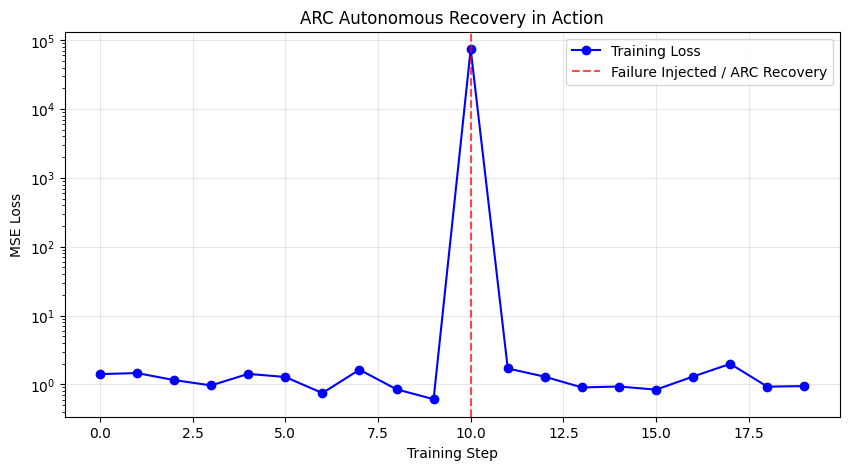

In [8]:
# Plotting the loss trajectory
plt.figure(figsize=(10, 5))
plt.plot(range(20), losses, marker='o', linestyle='-', color='b', label='Training Loss')

plt.axvline(x=10, color='r', linestyle='--', alpha=0.7, label='Failure Injected / ARC Recovery')

plt.title("ARC Autonomous Recovery in Action")
plt.xlabel("Training Step")
plt.ylabel("MSE Loss")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Conclusion: The Value of ARC
Notice the massive loss spike at **Step 10**? 

Normally, a huge error like this would completely ruin your model and force you to restart your training from scratch. 

But because we used ARC, it automatically saved the day:
* **Caught the error** instantly.
* **Threw away** the bad math.
* **Rolled back** to a safe checkpoint.
* **Lowered the learning rate** and kept training!

Using `ArcV2` protects your models from random crashes and saves you days of wasted time. Happy training!